In [1]:
import itertools
from enum import IntEnum
import numpy as np
import gutpython
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from tqdm.notebook import tqdm

In [2]:
%matplotlib inline

In [3]:
model = gutpython.GutPython(flow_dist=1.0)
model.setup()

In [4]:
# glucose_max = np.max(model.glucose + model.glucose_reserve)
# fo_max = np.max(model.fo + model.fo_reserve)
# lactose_max = np.max(model.lactose + model.lactose_reserve)
# lactate_max = np.max(model.lactate + model.lactate_reserve)
# inulin_max = np.max(model.inulin + model.inulin_reserve)
# for _ in range(1000):
#     model.go()
#     glucose_max = max(glucose_max, np.max(model.glucose + model.glucose_reserve))
#     fo_max = max(fo_max, np.max(model.fo + model.fo_reserve))
#     lactose_max = max(lactose_max, np.max(model.lactose + model.lactose_reserve))
#     lactate_max = max(lactate_max, np.max(model.lactate + model.lactate_reserve))
#     inulin_max = max(inulin_max, np.max(model.inulin + model.inulin_reserve))

# glucose_max, fo_max, lactose_max, lactate_max, inulin_max

observed_field_maxes = {
    'glucose': 30.0,
    'fo': 25.0,
    'lactose': 15.0,
    'lactate': 0.155,
    'inulin': 10.0,
}


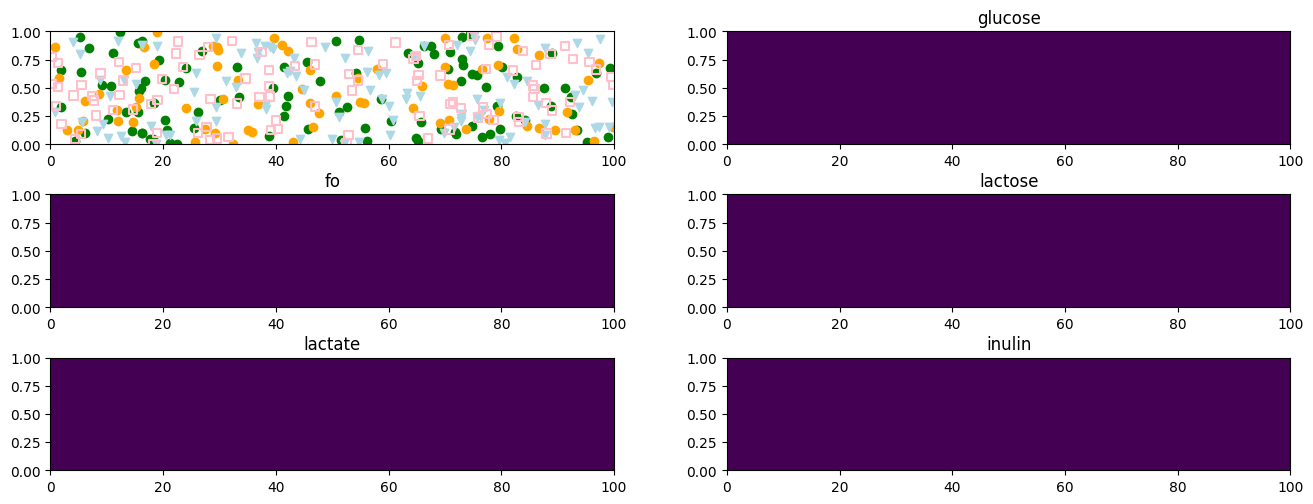

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(16, 6))

model.plot_agents(axs[0, 0])

for idx, field in enumerate(["glucose",
                             "fo",
                             "lactose",
                             "lactate",
                             "inulin", ]):
    r, c = divmod(idx + 1, 2)
    model.plot_field(axs[r, c], field_name=field, field_max=observed_field_maxes[field]*1.001)
    axs[r, c].set_title(field)

for r, c in itertools.product(range(3), range(2)):
    axs[r, c].set_aspect(20)

In [6]:
num_steps = 2000


class Task(IntEnum):
    html_anim = 0
    save_mpeg = 1
    make_hdf5 = 2


task = Task.html_anim

pbar = tqdm(total=num_steps, display=False)

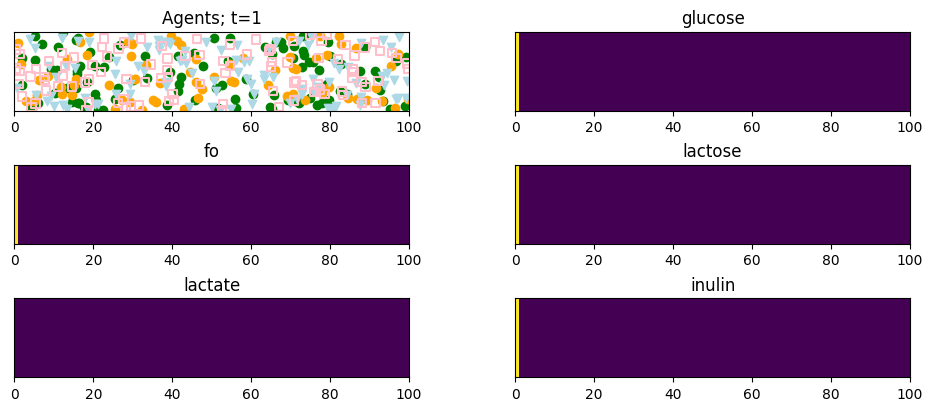

In [7]:
if task in {Task.html_anim, Task.save_mpeg}:

    mean_bacteroid_energy = []
    mean_bifido_energy = []
    mean_clost_energy = []
    mean_desulfo_energy = []

    bacteroid_count = []
    bifido_count = []
    clost_count = []
    desulfo_count = []
    
    fig, axs = plt.subplots(3, 2, figsize=(10, 4), layout="constrained")

    for r, c in itertools.product(range(3), range(2)):
        axs[r, c].set_aspect(20)


    def animate(i):
        model.go()
        pbar.update()

        mean_bacteroid_energy.append(
            np.mean(model.bacteroid_energy[model.bacteroid_mask]) if np.any(model.bacteroid_mask) else 0.0
        )
        mean_bifido_energy.append(
            np.mean(model.bifido_energy[model.bifido_mask]) if np.any(model.bifido_mask) else 0.0
        )
        mean_clost_energy.append(
            np.mean(model.clost_energy[model.clost_mask]) if np.any(model.clost_mask) else 0.0
        )
        mean_desulfo_energy.append(
            np.mean(model.desulfo_energy[model.desulfo_mask]) if np.any(model.desulfo_mask) else 0.0
        )

        bacteroid_count.append(model.num_bacteroids)
        bifido_count.append(model.num_bifidos)
        clost_count.append(model.num_closts)
        desulfo_count.append(model.num_desulfos)
        

        model.plot_agents(axs[0, 0])
        axs[0,0].set_title(f"Agents; t={model.ticks}")

        for idx, field in enumerate(["glucose",
                                     "fo",
                                     "lactose",
                                     "lactate",
                                     "inulin", ]):
            r, c = divmod(idx + 1, 2)
            model.plot_field(axs[r, c], field_name=field, field_max=observed_field_maxes[field]*1.001)
            axs[r, c].set_title(field)

        for r, c in itertools.product(range(3), range(2)):
            axs[r, c].set_aspect(20)
            axs[r,c].get_yaxis().set_visible(False)

        
        # # ax.set_aspect(1)

        # for k, field in enumerate(fields):
        #     row, col = divmod(k, 4)
        #     model.plot_field(axs[row, col], field_name=field)
        #     axs[row, col].set_title(field)
        #     axs[row, col].get_xaxis().set_visible(False)
        #     axs[row, col].get_yaxis().set_visible(False)
        #     axs[row, col].set_aspect(1)
        # for k in range(len(fields), 16):
        #     row, col = divmod(k, 4)
        #     axs[row, col].set_axis_off()


    pbar.update()
    anim = FuncAnimation(
        fig,
        animate,
        frames=num_steps,
        repeat=False,
        interval=100,  # half the default
    )

In [8]:
display(pbar.container)

if task == Task.html_anim:
    html_anim = HTML(anim.to_html5_video())
    display(html_anim)
elif task == Task.save_mpeg:
    anim.save("model-run.mpg")

  0%|          | 2/2000 [00:00<01:50, 18.05it/s]

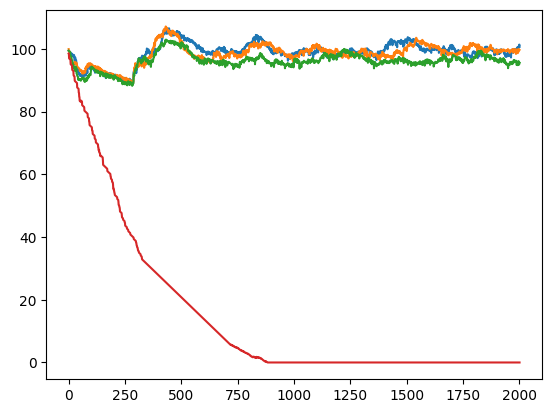

In [9]:
plt.plot(mean_bacteroid_energy)
plt.plot(mean_bifido_energy)
plt.plot(mean_clost_energy)
plt.plot(mean_desulfo_energy)

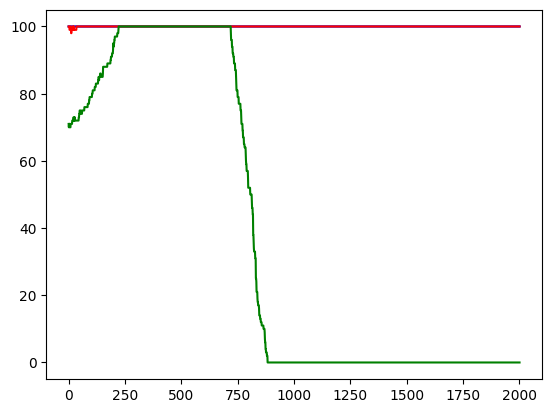

In [10]:
plt.plot(bacteroid_count, color='grey')
plt.plot(bifido_count, color='blue')
plt.plot(clost_count, color='red')
plt.plot(desulfo_count, color='green')

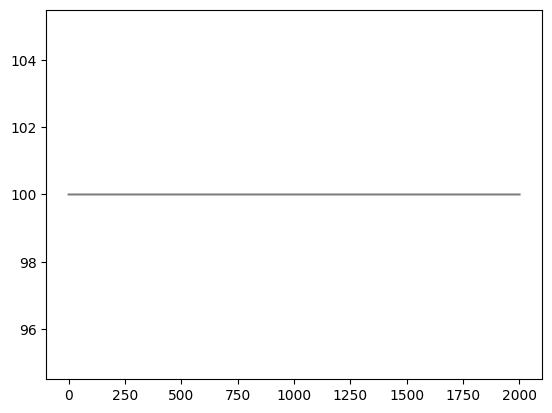

In [11]:
plt.plot(bacteroid_count, color='grey')